In [88]:
# Importing the libraries and loading the dataset 

import pandas as pd
import numpy as np

# Load datasets
df = pd.read_csv("Final_data.csv")

In [89]:
# Getting a summary of the dataset

df.describe

<bound method NDFrame.describe of          Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0      34.91    Male        65.27        1.62   188.58   157.65        69.05   
1      23.37  Female        56.41        1.55   179.43   131.75        73.18   
2      33.20  Female        58.98        1.67   175.04   123.95        54.96   
3      38.69  Female        93.78        1.70   191.21   155.10        50.07   
4      45.09    Male        52.42        1.88   193.58   152.88        70.84   
...      ...     ...          ...         ...      ...      ...          ...   
19995  46.77  Female        98.31        1.90   199.20   148.18        63.72   
19996  40.38  Female        88.12        1.87   196.18   134.18        54.04   
19997  50.31    Male        46.20        1.67   163.34   157.92        61.65   
19998  52.36    Male        44.30        1.62   179.27   121.23        60.88   
19999  29.56    Male        58.63        1.61   198.07   121.74        72.05   

     

In [90]:
# Checking the number of rows and columns

df.shape

(20000, 54)

In [91]:
# Finding Missing values 
# Since there were no null values, no further steps were taken. 

df.isnull().sum()

Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                      0
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
Daily meals frequency             0
Physical exercise                 0
Carbs                             0
Proteins                          0
Fats                              0
Calories                          0
meal_name                         0
meal_type                         0
diet_type                         0
sugar_g                           0
sodium_mg                         0
cholesterol_mg                    0
serving_size_g              

In [92]:
# Checking for duplicates and removing if any
# Since there were no duplicates in the dataset, not steps were performed.

duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

Number of duplicate rows: 0


In [93]:
# Checking the datatypes for all columns to make sure all have the correct datatypes. 

df.dtypes

Age                               float64
Gender                             object
Weight (kg)                       float64
Height (m)                        float64
Max_BPM                           float64
Avg_BPM                           float64
Resting_BPM                       float64
Session_Duration (hours)          float64
Calories_Burned                   float64
Workout_Type                       object
Fat_Percentage                    float64
Water_Intake (liters)             float64
Workout_Frequency (days/week)     float64
Experience_Level                  float64
BMI                               float64
Daily meals frequency             float64
Physical exercise                 float64
Carbs                             float64
Proteins                          float64
Fats                              float64
Calories                          float64
meal_name                          object
meal_type                          object
diet_type                         

In [94]:
'''Since age column had "Float" as the datatype to get a more realistic and practical age value, 
rounding off the age and converting it into an integer. '''


df['Age'] = df['Age'].round().astype(int)

In [95]:
# Checking the number of unique values for Age because merging needs to be performed on Age column

df['Age'].nunique()

43

In [96]:
# Shortlisting the columns based on the final result we want to achieve. 

columns_to_keep = [
    "Age",
    "Gender",
    "Weight (kg)",
    "Height (m)",
    "Calories_Burned",
    "Workout_Type",
    "Water_Intake (liters)",
    "Workout_Frequency (days/week)",
    "BMI",
    "Physical exercise",
    "Carbs",
    "Proteins",
    "Fats",
    "Calories",
    "meal_type",
    "diet_type",
    "sugar_g",
    "sodium_mg",
    "cholesterol_mg",
    "cooking_method",
    "Name of Exercise",
    "Burns Calories (per 30 min)",
    "Body Part",
    "Workout",
    "BMI_calc"
]

df1 = df[columns_to_keep]


In [97]:
''' Checking number of rows and columns in the dataset again after removing the ones 
that were not needed'''

df1.shape

(20000, 25)

In [98]:
# Saving the changes in a csv file with a new name

df1.to_csv("Lifestyle_dataset_NEW.csv", index=False)


In [99]:
df1.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Calories_Burned                  float64
Workout_Type                      object
Water_Intake (liters)            float64
Workout_Frequency (days/week)    float64
BMI                              float64
Physical exercise                float64
Carbs                            float64
Proteins                         float64
Fats                             float64
Calories                         float64
meal_type                         object
diet_type                         object
sugar_g                          float64
sodium_mg                        float64
cholesterol_mg                   float64
cooking_method                    object
Name of Exercise                  object
Burns Calories (per 30 min)      float64
Body Part                         object
Workout                           object
BMI_calc        

In [108]:
# Checking for outliers 

numeric_cols = ['Age', 'Weight (kg)', 'Height (m)', 'Calories_Burned', 'Water_Intake (liters)', 
                'Workout_Frequency (days/week)', 'BMI', 'Physical exercise', 'Carbs', 'Proteins', 
                'Fats', 'Calories', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 
                'Burns Calories (per 30 min)', 'BMI_calc']
print(df[numeric_cols].describe())


                Age   Weight (kg)    Height (m)  Calories_Burned  \
count  20000.000000  20000.000000  20000.000000     20000.000000   
mean      38.848850     73.898832      1.723093      1280.109600   
std       12.119206     21.173010      0.127033       502.228982   
min       18.000000     39.180000      1.490000       323.110000   
25%       28.000000     58.160000      1.620000       910.800000   
50%       40.000000     70.000000      1.710000      1231.450000   
75%       50.000000     86.100000      1.800000      1553.112500   
max       60.000000    130.770000      2.010000      2890.820000   

       Water_Intake (liters)  Workout_Frequency (days/week)           BMI  \
count           20000.000000                   20000.000000  20000.000000   
mean                2.627485                       3.318629     24.921680   
std                 0.604724                       0.911198      6.701126   
min                 1.460000                       1.940000     12.040000   
25

In [112]:
# Checking for outliers 

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for col in numeric_cols:
    outliers = detect_outliers_iqr(df1[col])
    print(f"{col} → Outliers count: {len(outliers)}")

Age → Outliers count: 0
Weight (kg) → Outliers count: 152
Height (m) → Outliers count: 0
Calories_Burned → Outliers count: 507
Water_Intake (liters) → Outliers count: 0
Workout_Frequency (days/week) → Outliers count: 0
BMI → Outliers count: 530
Physical exercise → Outliers count: 4695
Carbs → Outliers count: 405
Proteins → Outliers count: 403
Fats → Outliers count: 399
Calories → Outliers count: 102
sugar_g → Outliers count: 0
sodium_mg → Outliers count: 0
cholesterol_mg → Outliers count: 0
Burns Calories (per 30 min) → Outliers count: 893
BMI_calc → Outliers count: 529


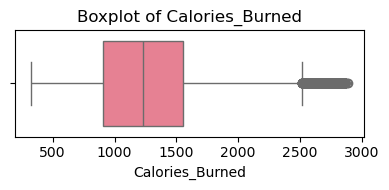

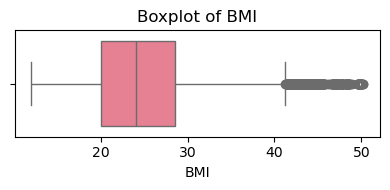

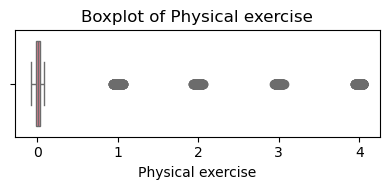

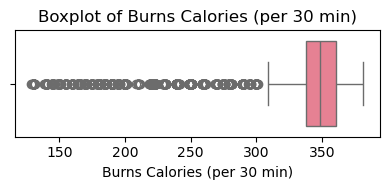

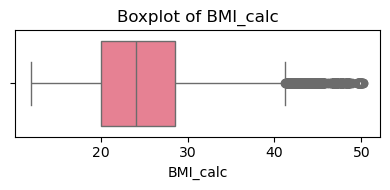

In [122]:
# Box plot to check in which direction the outliers are present. 

cols_500 = [
    "Calories_Burned",
    "BMI",
    "Physical exercise",
    "Burns Calories (per 30 min)",
    "BMI_calc"
]

for col in cols_500:
    plt.figure(figsize=(4, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


Observation:
- Calories_Burned: Mostly moderate values with a cluster of very high outliers.​
- BMI: Centered in low‑20s with many high‑BMI right‑tail outliers.​
- Physical exercise: Mass at zero; almost all actual exercise values are right‑side outliers.​
- Burns Calories (per 30 min): Compact high range with many unusually low‑burn outliers.​
- BMI_calc: Mirrors BMI, with several extreme high‑BMI outliers.

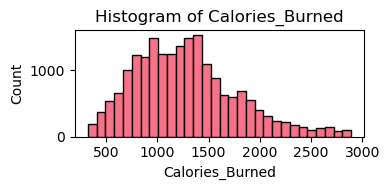

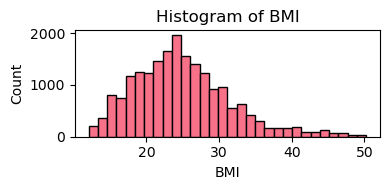

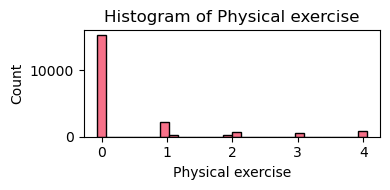

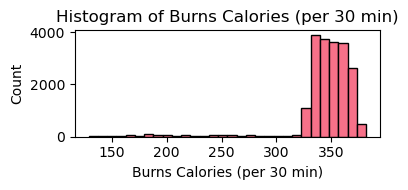

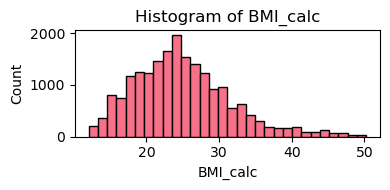

In [124]:
# Histograms: To See the Overall Shape of the data for the columns that have outliers. 

hist_cols = [
    "Calories_Burned",
    "BMI",
    "Physical exercise",
    "Burns Calories (per 30 min)",
    "BMI_calc",
]

for col in hist_cols:
    plt.figure(figsize=(4, 2))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


Observations:
- Calories_Burned: Most values lie around 800–1600, with fewer very high values stretching the right tail.
- BMI: Mostly between 20–30, with some higher values extending toward 50.
- Physical exercise: Almost everyone is at 0, with only a small fraction showing values from 1–4.
- Burns Calories (per 30 min): Densely concentrated near 330–370, with relatively few lower values.
- BMI_calc: Same pattern as BMI, centered near 20–30 with a thinner high‑value tail.

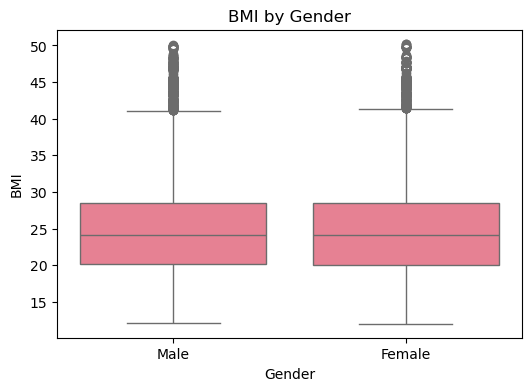

In [100]:
# Checking for relationship of BMI with gender or age. 

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Gender', y='BMI')
plt.title('BMI by Gender')
plt.ylabel('BMI')
plt.show()



Observations:
- The median BMI for males and females are almost the same
- Inter Quartile Range (middle 50%) is also almost the same
- Both genders show similar ranges and many high‑BMI outliers 

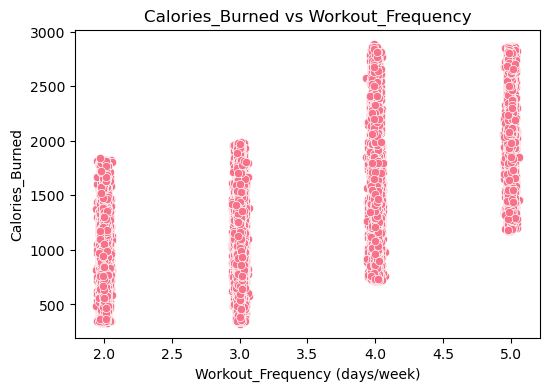

In [101]:
# Checking for relationship in Calories Burned and Workout Frequency
# More workout days → higher calories burned → can form stronger link to changes in stress level.

plt.figure(figsize=(6,4))
sns.scatterplot(data=df,
                x='Workout_Frequency (days/week)',
                y='Calories_Burned')
plt.title("Calories_Burned vs Workout_Frequency")
plt.show()


Why this plot ? 
- Since I wanted to compare 2 continous numeric variables , scatter plot is the standard way to show how one numeric variable changes
with respect to the other revealing patters (liner, increasing, or flat) at each frequency level. 

Observations:
- As the workout frequency increases, we see an evident rise in the calories burned.
- More workout days ≈ more calories burned per week

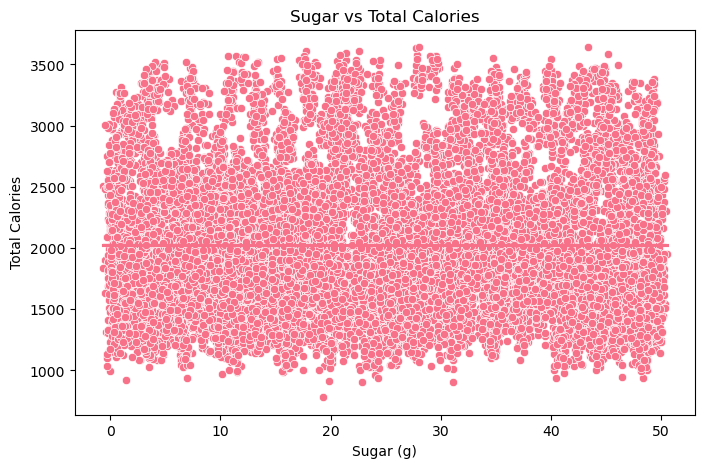

In [102]:
# 1. Sugar vs Calories Intake
# High sugar → calorie spikes → blood sugar crashes → stress ↑

plt.figure(figsize=(8,5))
sns.scatterplot(data=df1, x='sugar_g', y='Calories')
sns.regplot(data=df1, x='sugar_g', y='Calories', scatter=False)
plt.title('Sugar vs Total Calories')
plt.xlabel('Sugar (g)'); plt.ylabel('Total Calories')
plt.show()


Why this plot ?
- Scatter plot with a regression line because it is the standard, simplest way to see if two numeric 
variables (sugar and total calories) move together or no. 

Observations:
- As sugar increases, total calories are not clearly going up or down.
- For any sugar value, people can have both low and high total calories.
- This means sugar alone is not deciding how many total calories a person eats.

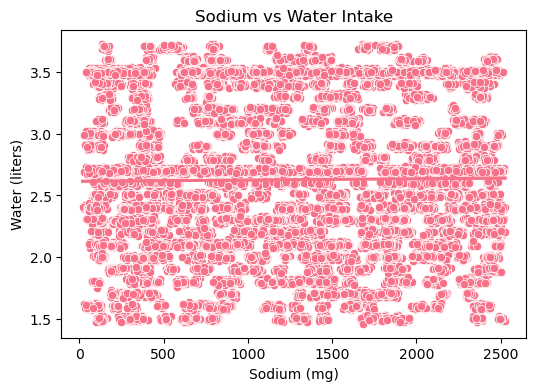

In [103]:
# 2. Sodium vs Water Intake
# Poor balance → dehydration → cortisol ↑ → stress ↑

plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='sodium_mg', y='Water_Intake (liters)')
sns.regplot(data=df1, x='sodium_mg', y='Water_Intake (liters)', scatter=False)
plt.title('Sodium vs Water Intake')
plt.xlabel('Sodium (mg)'); plt.ylabel('Water (liters)')
plt.show()


Why this plot ?
- A scatter plot with a regression line is the basic way to check if two numeric variables (sodium and water intake) move together or no. 

Observations:
- The dots are scattered across all water levels for both low and high sodium, so there is no clear pattern.
- The regression line is almost flat, meaning higher sodium does not clearly lead to higher or lower water intake.

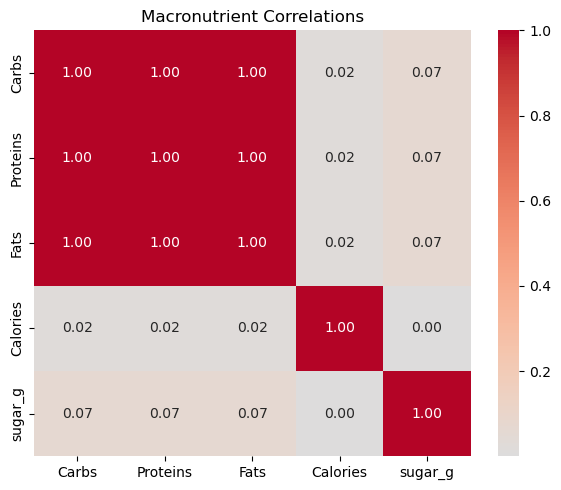

In [106]:
# 3. Macronutrients Heatmap
# Carb-dominant → energy volatility → stress sensitivity

nutr_cols = ['Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g']
corr = df1[nutr_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Macronutrient Correlations')
plt.tight_layout()
plt.show()


Why this plot ? 
- A heatmap lets you see all macronutrient correlation strengths in one clear picture, using color to instantly highlight which pairs are strongly related and which are not.

Observations:
- Carbs, Proteins and Fats are almost perfectly correlated with each other, and they more together as a group.
- There is no significant relationship of the Sugar with Calories 
- There is no significant relationship of Macros and Sugar with Calories 

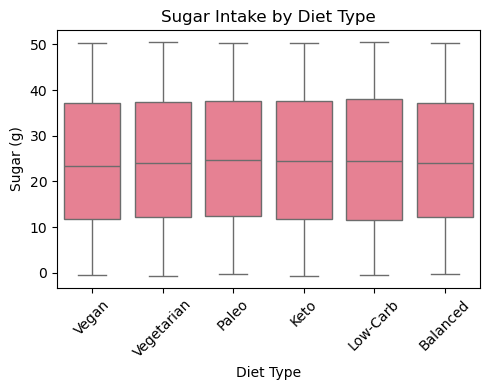

In [107]:
# 4. Sugar Intake by Diet Type
# Low-sugar diets → stable energy → stress resilience

plt.figure(figsize=(5,4))
sns.boxplot(data=df1, x='diet_type', y='sugar_g')
plt.title('Sugar Intake by Diet Type')
plt.xlabel('Diet Type'); plt.ylabel('Sugar (g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Why this plot ? 
- We chose the box plot since we wanted to compare a numerical variable over a categorical one. With the box plots its easy to check the distribution of data along with looking for potential outliers. 

Observations:
- The middle line of each box (median sugar) is at almost the same level for all diet types.
- The height of the boxes and whiskers is similar, so the variation in sugar intake is about the same for every diet.
- This means diet type is not changing how much sugar people are consuming
